## PROYECTO DE MACHINE LEARNING
### Clasificación de tipos de Cáncer

**Dataset:** TCGA PANCAN HiSeq — 801 muestras × 20,531 genes  
**Clases:** BRCA, KIRC, COAD, LUAD, PRAD  
**Pipeline:** Carga → Preprocesamiento → PCA → Clasificación → Evaluación

In [12]:
# Importar librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [14]:
# Cargar datos:
df = pd.read_csv('../data/data.csv', index_col=0)
labels = pd.read_csv('../data/labels.csv')
df

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.000000
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.000000
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.000000
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.000000
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample_796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,0.0,...,6.088133,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000
sample_797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,0.0,...,6.371876,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000
sample_798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,0.0,...,5.719386,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693
sample_799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,0.0,...,5.785237,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000


In [15]:
labels['Class'].value_counts()

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

## Machine Learning - Clasificación de Tumores

In [16]:
# Cargar librerias
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

# Seed para reproducibilidad
SEED = 42
np.random.seed(SEED)

In [17]:
X = df
y = labels['Class']

print(f'Shape features: {X.shape}')
print(f'Shape target:   {y.shape}')
print(f'\nDistribución de clases:')
print(y.value_counts())

Shape features: (801, 20531)
Shape target:   (801,)

Distribución de clases:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


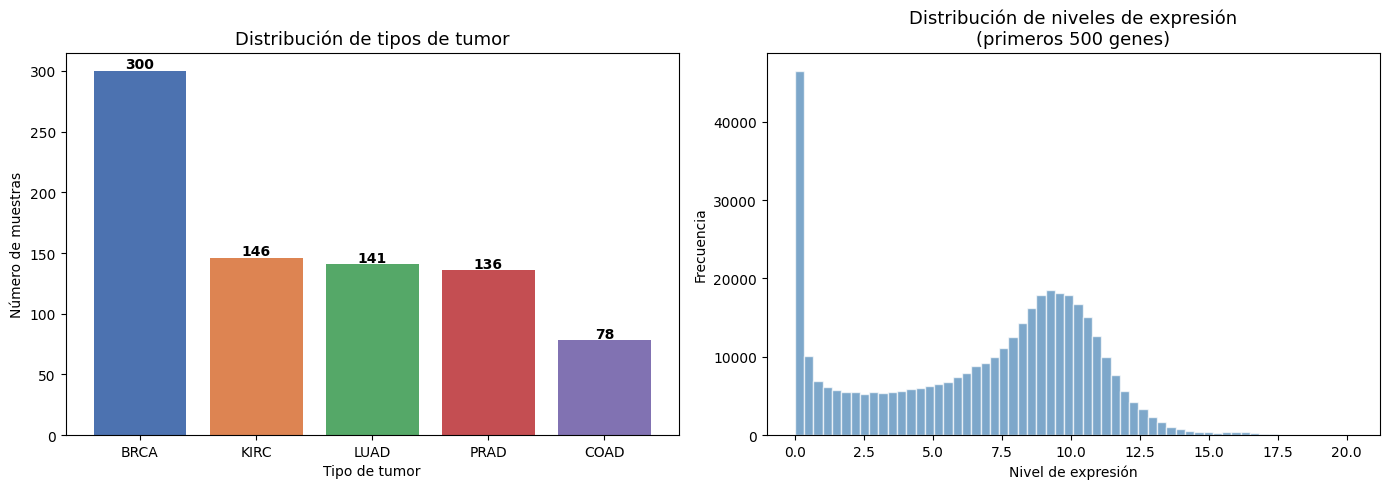

In [18]:
# Análisis exploratorio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de clases
counts = y.value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Distribución de tipos de tumor', fontsize=13)
axes[0].set_ylabel('Número de muestras')
axes[0].set_xlabel('Tipo de tumor')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Distribución de expresión génica (muestra de 500 genes aleatorios)
sample_genes = X.iloc[:, :500].values.flatten()
axes[1].hist(sample_genes, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribución de niveles de expresión\n(primeros 500 genes)', fontsize=13)
axes[1].set_xlabel('Nivel de expresión')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show();

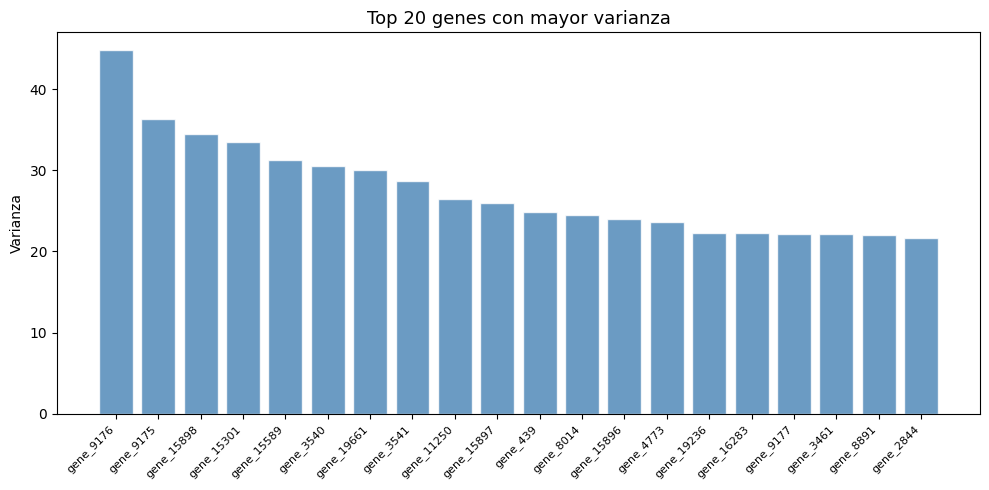

Gen con mayor varianza: gene_9176 (44.76)
Genes con varianza = 0: 267


In [20]:
# --- Plot 3: Top 20 genes más variables ---
gene_variance = X.var(axis=0)
top20_genes = gene_variance.nlargest(20)

plt.figure(figsize=(10, 5))
plt.bar(range(20), top20_genes.values, color='steelblue', alpha=0.8, edgecolor='white')
plt.xticks(range(20), top20_genes.index, rotation=45, ha='right', fontsize=8)
plt.title('Top 20 genes con mayor varianza', fontsize=13)
plt.ylabel('Varianza')
plt.tight_layout()
plt.show()

print(f'Gen con mayor varianza: {top20_genes.index[0]} ({top20_genes.iloc[0]:.2f})')
print(f'Genes con varianza = 0: {(gene_variance == 0).sum()}')

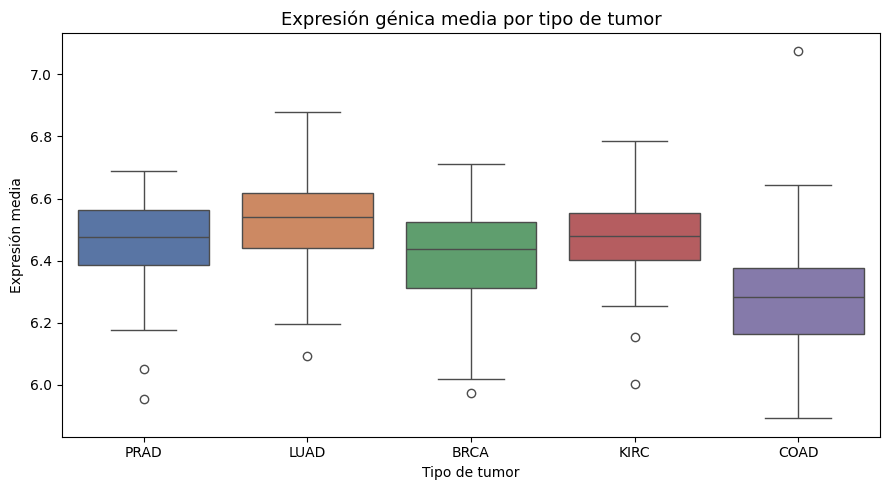

In [23]:
# --- Plot 4: Boxplot de expresión media por tipo de tumor ---
X_mean = X.mean(axis=1)
df_plot = pd.DataFrame({'expresion_media': X_mean, 'tumor': y.values})

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_plot, x='tumor', y='expresion_media', hue='tumor',
            palette=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'],
            legend=False)
plt.title('Expresión génica media por tipo de tumor', fontsize=13)
plt.xlabel('Tipo de tumor')
plt.ylabel('Expresión media')
plt.tight_layout()
plt.show()

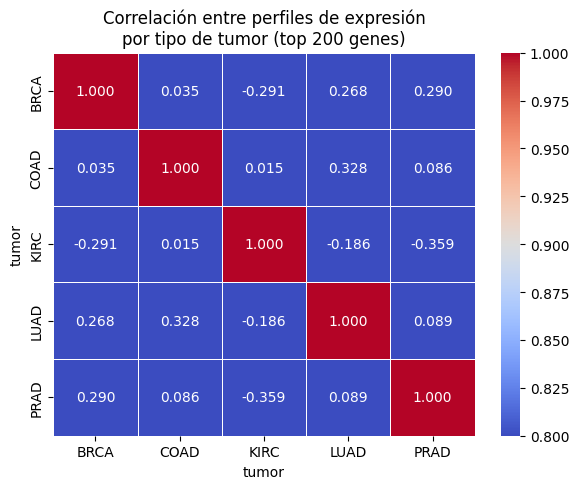

In [24]:
# Heatmap de correlación entre tipos de tumor ---
# Media de expresión por clase (usando los 200 genes más variables)
top200 = gene_variance.nlargest(200).index
X_top200 = X[top200].copy()
X_top200['tumor'] = y.values

corr_matrix = X_top200.groupby('tumor').mean().T.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0.8, vmax=1.0, linewidths=0.5)
plt.title('Correlación entre perfiles de expresión\npor tipo de tumor (top 200 genes)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Codificar etiquetas
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Clases codificadas:', dict(zip(le.classes_, le.transform(le.classes_))))

# Verificar valores nulos
print(f'\nValores nulos: {X.isnull().sum().sum()}')

# Split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc)

# Escalar (estandarización)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nTrain: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Clases codificadas: {'BRCA': np.int64(0), 'COAD': np.int64(1), 'KIRC': np.int64(2), 'LUAD': np.int64(3), 'PRAD': np.int64(4)}

Valores nulos: 0

Train: (640, 20531) | Test: (161, 20531)


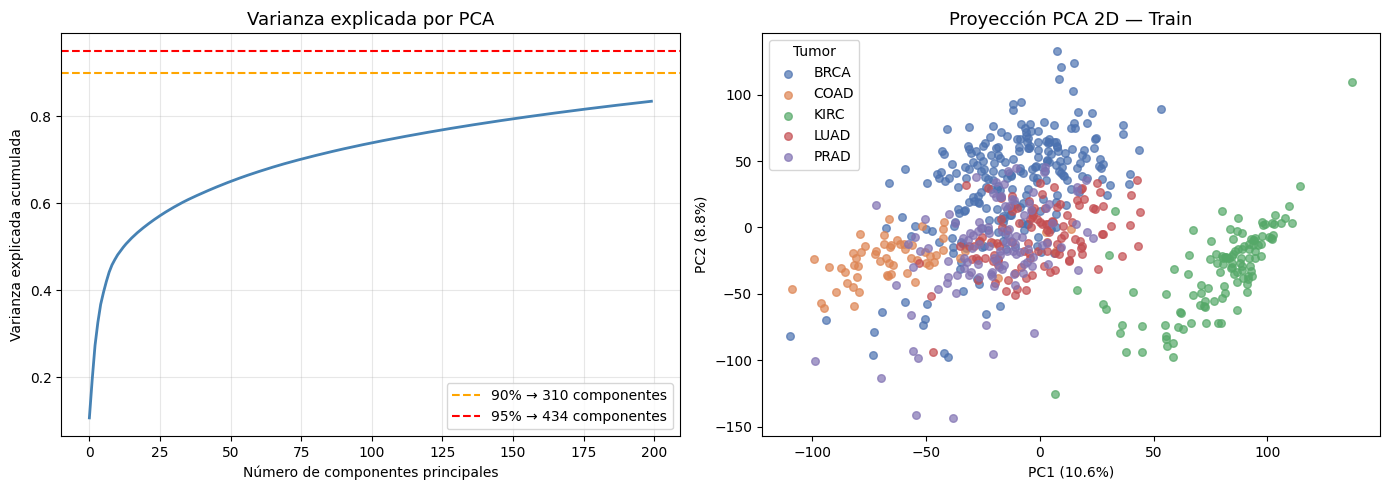


Componentes para 90% varianza: 310
Componentes para 95% varianza: 434


In [26]:
# PCA para analizar varianza explicada
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza acumulada
axes[0].plot(cumvar[:200], color='steelblue', linewidth=2)
axes[0].axhline(0.90, color='orange', linestyle='--', label=f'90% → {n_90} componentes')
axes[0].axhline(0.95, color='red', linestyle='--', label=f'95% → {n_95} componentes')
axes[0].set_xlabel('Número de componentes principales')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].set_title('Varianza explicada por PCA', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Proyección 2D
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_train_scaled)
colors_map = {0:'#4C72B0', 1:'#DD8452', 2:'#55A868', 3:'#C44E52', 4:'#8172B2'}
for cls in np.unique(y_train):
    mask = y_train == cls
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    label=le.classes_[cls], alpha=0.7,
                    color=colors_map[cls], s=30)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Proyección PCA 2D — Train', fontsize=13)
axes[1].legend(title='Tumor')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nComponentes para 90% varianza: {n_90}')
print(f'Componentes para 95% varianza: {n_95}')

In [28]:
# Aplicar PCA con N componentes que explican 95% de varianza
N_COMPONENTS = n_95

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Dimensiones originales: {X_train_scaled.shape[1]}')
print(f'Dimensiones tras PCA:   {X_train_pca.shape[1]}')
print(f'Reducción: {(1 - N_COMPONENTS/X_train_scaled.shape[1])*100:.1f}%')

Dimensiones originales: 20531
Dimensiones tras PCA:   434
Reducción: 97.9%


In [29]:
# Definir clasificadores a comparar
classifiers = {
    'SVM (RBF)':         SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED),
    'Random Forest':     RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print('Evaluando clasificadores con validación cruzada (5-fold)...\n')
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_train_pca, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:<25} Acc: {scores.mean():.4f} ± {scores.std():.4f}')

Evaluando clasificadores con validación cruzada (5-fold)...

SVM (RBF)                 Acc: 0.9891 ± 0.0063
Random Forest             Acc: 0.9187 ± 0.0207
Logistic Regression       Acc: 0.9984 ± 0.0031


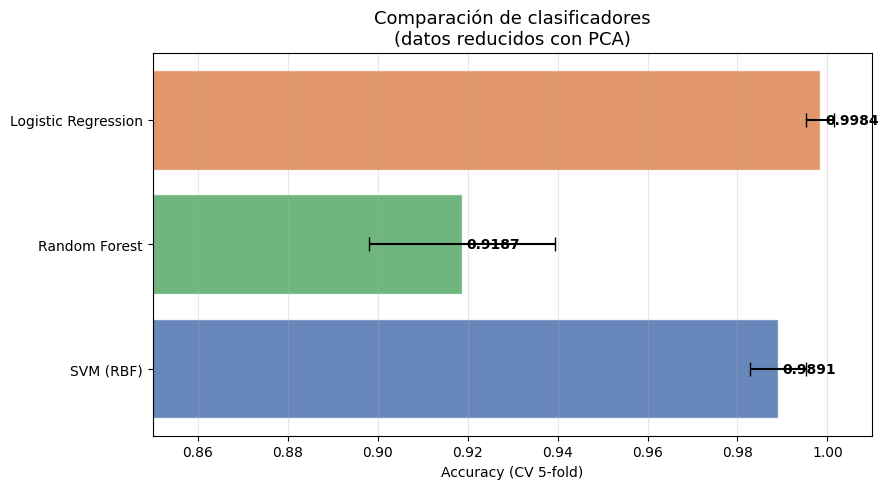

In [30]:
# Visualizar comparación de modelos
fig, ax = plt.subplots(figsize=(9, 5))

names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]

bars = ax.barh(names, means, xerr=stds, color=['#4C72B0','#55A868','#DD8452'],
               capsize=5, alpha=0.85, edgecolor='white')
ax.set_xlabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de clasificadores\n(datos reducidos con PCA)', fontsize=13)
ax.set_xlim(0.85, 1.01)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.001, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [31]:
# Entrenar el mejor modelo
best_clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
best_clf.fit(X_train_pca, y_train)

y_pred = best_clf.predict(X_test_pca)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 1.0000

              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



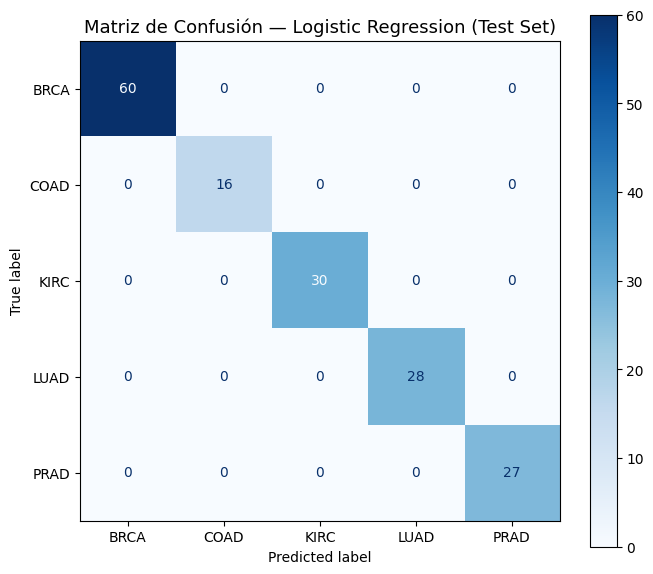

In [33]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — Logistic Regression (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

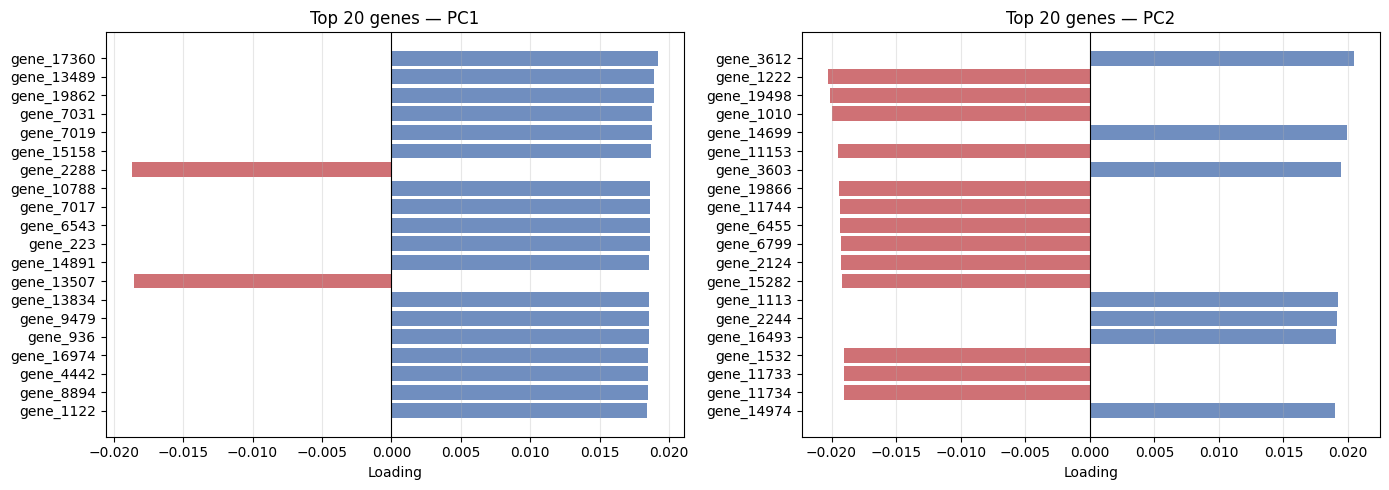

In [34]:
# Top genes más influyentes en PC1 y PC2
gene_names = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, ax in enumerate(axes):
    loadings = pca.components_[i]
    top_idx = np.argsort(np.abs(loadings))[-20:][::-1]
    top_genes = [gene_names[j] for j in top_idx]
    top_vals  = loadings[top_idx]
    
    colors_bar = ['#4C72B0' if v > 0 else '#C44E52' for v in top_vals]
    ax.barh(top_genes[::-1], top_vals[::-1], color=colors_bar[::-1], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top 20 genes — PC{i+1}', fontsize=12)
    ax.set_xlabel('Loading')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=120, bbox_inches='tight')
plt.show()

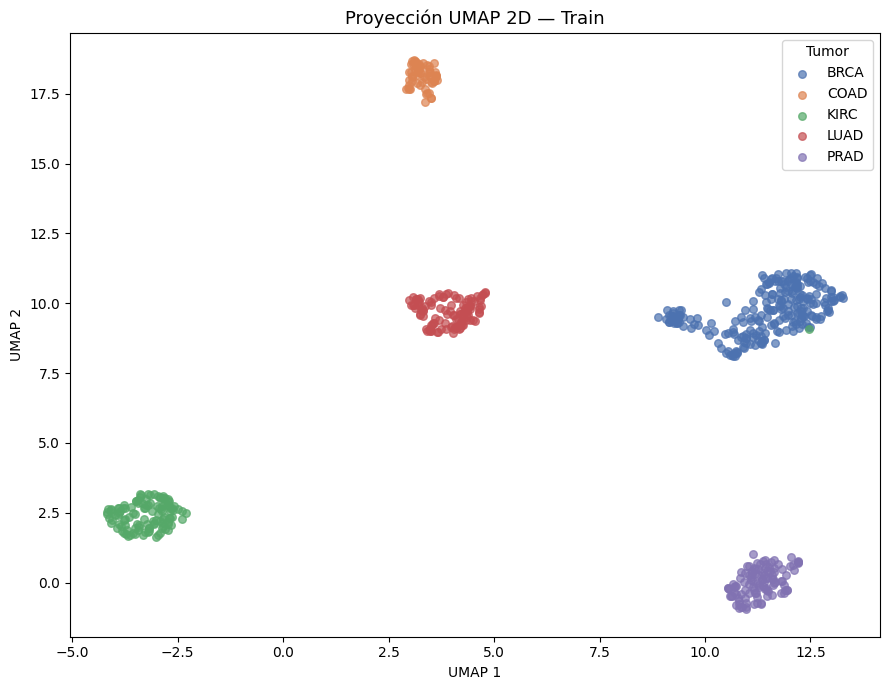

In [36]:
import umap

# Ajustar UMAP sobre los datos escalados
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_train_scaled)

# Visualizar
colors_map = {0:'#4C72B0', 1:'#DD8452', 2:'#55A868', 3:'#C44E52', 4:'#8172B2'}

plt.figure(figsize=(9, 7))
for cls in np.unique(y_train):
    mask = y_train == cls
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                label=le.classes_[cls], alpha=0.7,
                color=colors_map[cls], s=30)

plt.title('Proyección UMAP 2D — Train', fontsize=13)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Tumor')
plt.tight_layout()
plt.show()

In [37]:
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Definir nuevos clasificadores
new_classifiers = {
    'XGBoost':     XGBClassifier(n_estimators=200, learning_rate=0.1, 
                                  max_depth=6, random_state=SEED,
                                  eval_metric='mlogloss', verbosity=0),
    'AdaBoost':    AdaBoostClassifier(n_estimators=200, learning_rate=0.5,
                                       random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Evaluando nuevos modelos con validación cruzada (5-fold)...\n')
for name, clf in new_classifiers.items():
    scores = cross_val_score(clf, X_train_pca, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores  # añade al dict results que ya tienes
    print(f'{name:<25} Acc: {scores.mean():.4f} ± {scores.std():.4f}')

Evaluando nuevos modelos con validación cruzada (5-fold)...

XGBoost                   Acc: 0.9750 ± 0.0104
AdaBoost                  Acc: 0.9578 ± 0.0063


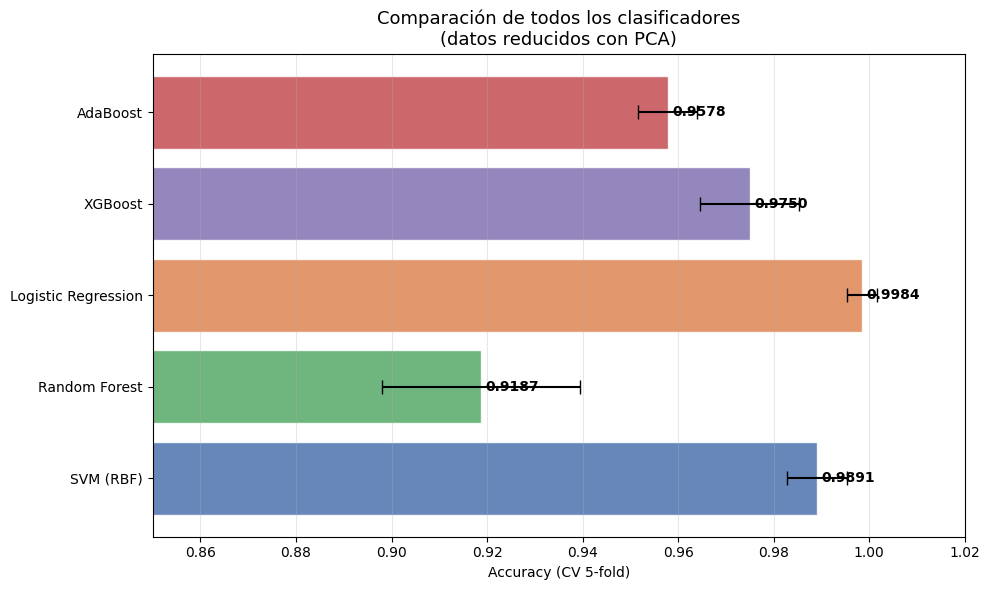

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

names = list(results.keys())
means = [results[n].mean() for n in names]
stds  = [results[n].std()  for n in names]
colors_bar = ['#4C72B0', '#55A868', '#DD8452', '#8172B2', '#C44E52']

bars = ax.barh(names, means, xerr=stds, color=colors_bar,
               capsize=5, alpha=0.85, edgecolor='white')
ax.set_xlabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de todos los clasificadores\n(datos reducidos con PCA)', fontsize=13)
ax.set_xlim(0.85, 1.02)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.001, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Resetear índices para alinear X e y
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Ahora sí funciona el filtro
mask_brca = y == 'BRCA'
X_brca = X[mask_brca]

print(f'Muestras BRCA: {X_brca.shape[0]}')

Muestras BRCA: 300


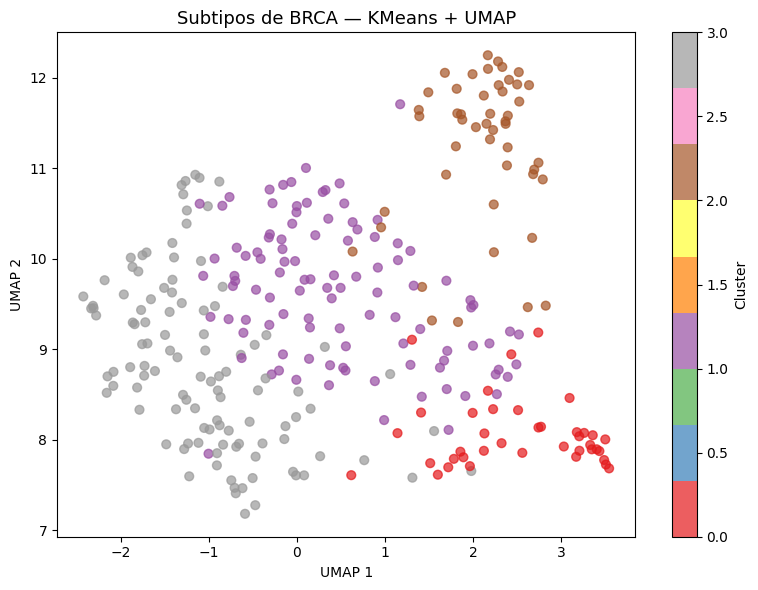

In [41]:
# Filtrar solo BRCA
mask_brca = y == 'BRCA'
X_brca = X[mask_brca]

# Clustering no supervisado (no tenemos etiquetas de subtipo)
from sklearn.cluster import KMeans

scaler_brca = StandardScaler()
X_brca_scaled = scaler_brca.fit_transform(X_brca)

pca_brca = PCA(n_components=50, random_state=SEED)
X_brca_pca = pca_brca.fit_transform(X_brca_scaled)

kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_brca_pca)

# Visualizar con UMAP
reducer_brca = umap.UMAP(n_components=2, random_state=SEED)
X_brca_umap = reducer_brca.fit_transform(X_brca_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_brca_umap[:, 0], X_brca_umap[:, 1],
                      c=clusters, cmap='Set1', alpha=0.7, s=40)
plt.colorbar(scatter, label='Cluster')
plt.title('Subtipos de BRCA — KMeans + UMAP', fontsize=13)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

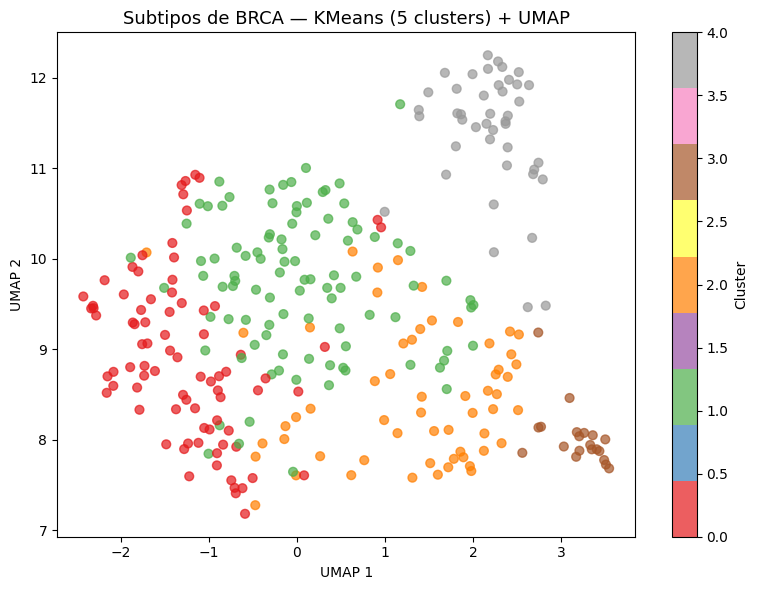

In [42]:
kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_brca_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_brca_umap[:, 0], X_brca_umap[:, 1],
                      c=clusters, cmap='Set1', alpha=0.7, s=40)
plt.colorbar(scatter, label='Cluster')
plt.title('Subtipos de BRCA — KMeans (5 clusters) + UMAP', fontsize=13)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

# Crear carpetas si no existen
os.makedirs('../model/production', exist_ok=True)

# Guardar todos los modelos comparados
for name, clf in classifiers.items():
    clf.fit(X_train_pca, y_train)  # entrenar con todos los datos de train
    filename = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(clf, f'../model/{filename}.pkl')
    print(f'Guardado: {filename}.pkl')

# Guardar también XGBoost y AdaBoost
for name, clf in new_classifiers.items():
    clf.fit(X_train_pca, y_train)
    filename = name.lower().replace(' ', '_')
    joblib.dump(clf, f'../model/{filename}.pkl')

# Modelo final en production/
joblib.dump(best_clf, '../model/production/logistic_regression_pca.pkl')
print('✅ Modelo de producción guardado.')